# UNO Vision

Image Analysis and Pattern Recognition - Final Project

Group 34

Fiona Dematraz (333322) & Killian Ballifard (393385) & Gabriel Marival (395778)

**DISCLAIMER** : All scripts including this notebook expects data from kaggle to be located in **this_notebook_folder/data/\*\*** folder. Data was not included in the submission.

## 0 Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

from project.scripts.dataset import load_train_images_paths_and_labels
from project.scripts.token import detect_active_player, is_white_background

from scripts.dataset import load_train_image, PARENT_PATH, CARDS_COUNT, Card
from scripts.preprocessing.sectors import slice_sectors
from scripts.preprocessing.colors import show_ref_cards_color_stats
from scripts.preprocessing.rygb import hsv2rygb, rygb2rgb
from scripts.preprocessing.filter import area_bandpass_filter
from scripts.preprocessing.crop import crop
from scripts.preprocessing import preprocess

from scripts.classifiers.pattern import PatternMatcher
from scripts.dataset.synthesizer import Synthesizer

## 1 Introduction

Automatically understanding the state of a game from a visual input is a complex problem that combines object detection, classification, and spatial reasoning. For the project, this problem is placed in the context of the game UNO, with the goal of inferring the complete state of a game from a single top-down photograph of the table.

From a single image, the system must predict the central card in play, the active player, and the set of cards held by each of the four players. Players occupy fixed spatial positions around the table, and the active player is indicated by a physical token placed next to their hand. The dataset presents two main difficulties: the background variability (plain white vs. noisy patterned) and the card layout complexity (non-overlapping vs. overlapping).

To address this, a pipeline was designed with two parallel branches: one for detecting the active token via color segmentation and shape filtering, and the other for card recognition, which divides the image into spatial sectors, converts them to a custom 4-channel RYGB color representation, and classifies each sector using template matching via normalized cross-correlation against a library of 
reference card patterns. The final game state is assembled by combining the two outputs and evaluated using a weighted score of center card accuracy (10%), active player accuracy (10%), and per-player F1 score (80%).

## 2 Dataset

The dataset consists of top-down photographs taken during actual UNO games, captured under a variety of conditions. There are two types of backgrounds: plain white backgrounds, which provide a clean, easy-to-segment environment, and backgrounds with busy patterns (such as a tablecloth with leaf patterns), which make isolating the cards significantly more difficult. For each background type, the dataset includes both non-overlapping and overlapping card layouts, with the latter being more challenging to process because the card edges are partially obscured.

Each image depicts up to four players positioned at fixed locations around the table (bottom, right, top, left), though not all images necessarily contain four players. In the center of the table is the active discard pile. The active player is indicated by a physical token—a small dark cube or a yellow coin—placed next to their hand of cards.

The cards fall into 54 distinct categories: number cards (0–9) in four colors (red, green, blue, yellow), as well as action cards (Pass, Reverse, Draw Two) and wild cards (Wild, Wild Draw Four).

## 3 Methodology 

### 3.1 Overview

<p align="center">
    <img src="figures/iapr_figures-Overall pipeline.png" width="700"/>
</p>

The pipeline takes a single top-down RGB image of size 
$4000 \times 2662 \times 3$ as input and processes it through two parallel branches, as illustrated in the Figure.

The first branch handles active player detection, locating the physical token on the table and assigning it to one of the four player zones. The second branch handles card recognition, passing the image through a preprocessing stage that produces 
$512 \times 256 \times 4$ RYGB tensors, which are then classified against a library of $54$ reference card patterns. The two outputs are finally combined to assemble the complete game state.

### 3.2 Active Token Detection

#### 3.2.1 Overview

The goal of this branch is to find the active player token in the image and assign it to one of the four player zones.

<p align="center">
    <img src="figures/iapr_figures-Active player.png" width="500"/>
</p>

#### 3.2.2 Step 1 : Background Detection

The first step determines which type of token to look for. The four corners of the image are sampled, which always contain background and never cards. If the mean brightness of these corners exceeds 200, the scene is classified as a white background; otherwise, it is classified as a flower background. This distinction lets know which token types are: white background always use a black rectangular token, while flower background always use a yellow circular token.

#### 3.2.3 Step 2 : Color Masking

Depending on the background type, a binary mask is computed on the full image.

- **White background** : an HSV threshold with `V < 130` and `S < 90` is applied to isolate dark pixels corresponding to the black token. Morphological closing (15×15 kernel) fills internal gaps, followed by opening (7×7 kernel) to remove noise.
- **Flower background** : the preprocessing pipeline's color segmentation function, already calibrated for UNO card colors,is used to produce a soft yellow confidence map, which is then thresholded at 40 to obtain a binary mask.

#### 3.2.4 Step 3 : Blob Selection

For each contour extracted from the binary mask, a set of shape descriptors is computed:

| Descriptor | Formula | Ideal value |
|---|---|---|
| Circularity | `4π × area / perimeter²` | 1.0 = perfect circle |
| Solidity | `area / convex_hull_area` | 1.0 = fully solid |
| Aspect ratio | `max(w,h) / min(w,h)` | 1.0 = square |
| Rect fill *(black only)* | `area / minAreaRect_area` | 1.0 = solid rectangle |
| Yellow density *(yellow only)* | fraction of yellow pixels inside blob | filters hollow symbols |

**Yellow token selection** : a candidate must satisfy:
- `circularity > 0.65` (round shape)
- `solidity > 0.65` (solid interior)
- `yellow_density > 0.55` (uniformly filled — rejects Skip card circles which have white holes)

The blob maximizing `circularity × solidity × yellow_density` is selected.

**Black token selection** : a candidate must satisfy:
- `circularity < 0.82` (non-circular, i.e. rectangular)
- `aspect_ratio > 1.1` (elongated)
- `rect_fill > 0.65` (solid rectangle, not a hollow card symbol)

Among valid candidates, the largest blob by area is retained, as the token is the biggest dark solid object in the scene.

#### 3.2.5 Step 4 : Player Assignment

The centroid `(cx, cy)` of the detected token is mapped to the nearest player zone using Euclidean distance:

```
active_player = argmin_p  distance(token_center, player_zone_center_p)
```

The four zone centers are fixed image coordinates corresponding to P1 (bottom), P2 (right), P3 (top), and P4 (left).



### 3.3 Preprocessing 

#### 3.3.1 Overview

The preprocessing pipeline takes a raw **RGB** image of shape $2662 \times 4000 \times 3$ and produces $5$ normalized **RYGB** color maps of shape $5 \times 1024 \times 2048 \times 4$, one per player zone and the center, ready to be fed into the classifier. Each step is applied independently to each sector.

<p align="center">
    <img src="figures/iapr_figures-Preprocessing.png" width="1200" />
</p>

#### 3.3.2 Step 1 : Sectors Splitting

The image is divided into $5$ fixed rectangular sectors of size $2048 \times 1024$ pixels, corresponding to the center pile and the four player zones (**P1** bottom, **P2** right, **P3** top, **P4** left). Since players are positioned on all four sides of the table, sectors for **P2**, **P3** and **P4** are rotated to a **canonical orientation** :

- **P2** (right): rotated $90$° clockwise
- **P3** (top): rotated $180$°
- **P4** (left): rotated $90$° counter-clockwise

<p align="center">
    <img src="figures/iapr_figures-Sectors.png"  width="450"/>
</p>

After reorientation, all sectors share the same $2048 \times 1024$ layout with cards always appearing in the same reading direction, giving a tensor of shape $5 \times 2048 \times 1024 \times 3$. Because sectors of that size would take too much computationnal power later on, they are **downscaled** by $4$ to $5 \times 512 \times 256 \times 3$, which leaves the card recognizable while making the size manageable.

#### 3.3.3 Step 2 : RYGB Soft Segmentation

After splitting, each sector is converted to a custom **RYGB** color space. This is more representative of the features we want to isolate.

To achieve this, each sector is first converted from **RGB** to **HSV**, which separates chromatic information (hue, saturation) from brightness (value), making color identification more robust to lighting variations.

Then cards are converted from the **HSV** color space into a custom **RYGB** color space. This is done as a **soft segmentation**, not binarizing the image, but encoding each pixel's color distance to each channel. The black component of *draw 4* and *wild* cards is computed separately using the same approach. It is then added to all four channels, so that black becomes the white of this **RYGB** color space.

<p align="center">
    <img src="figures/iapr_figures-RYGB.png" width="800"/>
</p>

The metric for this conversion is derived from the color distribution of the reference cards (manually soft segmented), by computing the **mean** and **standard deviation** of each color. For this to work, **hue** must be **wrapped around** $180$°. Then during conversion, a pixel landing on the mean color is set to $255$, while a pixel landing at $6 \cdot \sigma$ of any the characteristic is set to $0$. Any pixel within $\mu \pm 6 \cdot \sigma$ is assigned an intermediate value (except for hue and satuaration of black which are kept at $\mu \pm \sigma$, otherwise most shadows would be counted in).

#### 3.3.4 Step 3 : Area Bandpass Filtering

On images with a "flower" background, changing color space is not sufficient to completely get rid of the background. However, on the soft segmentation results, we can notice that the white contour of each card effectively separates cards regions from the background regions.

Using **region growing**, we can filter out any region with an area outside the area bands a card can occupy (around $[250, 25'000] \text{px}^2$ for $512 \times 256$ images). For this we must first **blend** all $4$ channels of the **RYGB** image together, so that regions can be counted more effectively. Then a **mask** is computed from combining regions that are within the area bands. This mask is then applied on all $4$ channels of the **RYGB** image to only keep the cards regions.

<p align="center">
    <img src="figures/iapr_figures-Background removal.png" width="700"/>
</p>

#### 3.4 Classification

#### 3.4.1 Pattern matching

Card classification is performed by **template matching** using normalized cross-correlation. For each card class $i$, a reference pattern is loaded from the card image library, downscaled by a factor of 4 using area interpolation (`cv2.INTER_AREA`), and converted to the RYGB color space.

The similarity score $s_i$ between an input image and reference pattern $i$ is computed as:

$$s_i = \frac{1}{4} \sum_{c=1}^{4} \max_{\theta,\, \lambda,\, (x,y)} R_c^{(i)}(x, y, \theta, \lambda)$$

where $R_c^{(i)}$ is the normalized cross-correlation map (`TM_CCOEFF_NORMED`) between channel $c$ of the input image and channel $c$ of the $i$-th reference pattern, after applying rotation $\theta$ and scale $\lambda$. The rotation $\theta$ is sampled uniformly over 32 values in $[-\pi, \pi)$ and the scale $\lambda$ over 8 values in $[0.9, 1.1)$. Taking the maximum over all spatial positions $(x, y)$ makes the score invariant to card location within the image.

The metric `TM_CCOEFF_NORMED` produces scores in $[-1, 1]$, where $1$ corresponds to a perfect match, independently of absolute pixel intensity. The final prediction is the class $i^* = \arg\max_i \, s_i$.

#### 3.4.2. Machine learning

Machine learning approaches, and convolutional neural networks in particular, are well suited 
to this detection type of problem as they can learn rich visual representations directly from data, automatically 
capturing the relevant features — color, shape, printed symbols — that distinguish one card 
from another. We will present the different elements of our machine learning approach.

##### 3.4.2.1. Data synthetizer

Due the scarsity of training data (81 training samples), we decided to implement a data synthetizer to generate data at scale.
Indeed, machine learning models, especially (with the constraint of not using pretrained model) require large amounts of labeled examples to generalize effectively, and performance tends to degrade significantly when trained on small datasets. This is what we observed with our model not being able to learn when using only the given training data.


The synthetizer works in the following way :                                                                                                                                                    
                                                                                                                                                                                                          
  It generates individual sector images (not full game states), one sector at a time:                                                                                                                     
                                                                                                                                                                                                          
  1. Background — randomly picks a gray or flower background image for one of the 4 player zones (or center zone)                                                                                         
  2. Cards — picks 0–4 random cards, alpha-blends them onto the background at randomized positions, angles, and spacing (stacked or spread) - to simulate the different game setups (overlaps). Center sector always gets exactly 1 card.                  
  3. Illumination — adds ambient noise, a directional diffuse gradient, and a specular hotspot to simulate real lighting                                                                                  
  4. Output — resizes to (512, 256) RGB + a 54-dim binary label vector (1 where a card appears)                                                                                                           
                                                                                                                                                                                                          
  Then at training time, we assemble the synthetic game states : picks 1 center sector (single-card) + 4 random player sectors and stacks them into the (5, H, W, 4) format the model expects

The goal of this synthetizer is to provide us with synthetic data that closely mirrors the statistical and semantic properties of our original training set, in order to enhance the feature learning of our model.


##### 3.4.2.2. Data augmentation

Data augmentation is a technique to artificially create new images by applying tranformations to the initial dataset. We applied classic transformations to our dataset such as random flip (vertical or horizontal) - grayscale transformation (to enhance shape features learning) - gaussian blur - random cropping ...
Those augmentations are really important as they allow a larger pool of data and also is powerful form of regularization that helps reduce overfitting by introducing more diversity into the training set.
This is very important to ensure the generalization of a model on unseen data. 

##### 3.4.2.3. Model architecture

EfficientNet is a family of highly efficient Convolutional Neural Networks (CNNs) used primarily for computer vision tasks like image classification and object detection. 
The key concept of EfficientNet models is a scaling method that uniformly scales all dimensions of depth/width/resolution using a simple yet highly effective compound coefficient.

EfficientNet-B0 consists of a stem, seven distinct stages of mobile inverted bottleneck blocks (MBConv), and a final classification head. Its structure is defined by the following key components:

1. Stem : Initial Layer with a standard convolution

2. MBConv (Mobile Inverted Bottleneck): The building block of EfficientNet, originally introduced with MobileNetV2. It utilizes an "inverted" structure that expands the number of channels before applying a lightweight depthwise convolution and subsequently projecting the channels back to a lower dimension. This minimizes the computational bottleneck while maintaining high-dimensional feature information.

3. Squeeze-and-Excitation (SE) Optimization: Integrated into every MBConv block, the SE module provides a channel-wise attention mechanism. It allows the network to adaptively recalibrate the importance of different feature maps, effectively "squeezing" global spatial information into a descriptor to "excite" the most relevant channels.

4. Swish Activation Function: EfficientNet replaces the standard ReLU activation with Swish (f(x)=x⋅sigmoid(x)). This non-monotonic, smooth function has been shown to improve the gradient flow during training and enhance the model’s ability to learn complex representations.

Small changes were made to fit our pipeline - and the rest was left unchanged.
Mainly we needed to customize the first convolution layer to accept a given initial number of channels - 4 with the RYGB channel, (or even more if we use Sobel-edge detection operator  etc...)

##### 3.4.2.4. Training Choices and Setup

A very important choice in our training setup was the loss function.

One of the first important aspects is that the labels produced by the model are very sparse. For example, predicting 0 everywhere trivially yields a "good prediction" since the vast majority of the 54-dimensional label vector will indeed be 0s. This class imbalance needed to be explicitly addressed in the choice of loss function.

We tested two losses:

1. **BCE Loss with Logits:** A standard binary cross-entropy for multi-label classification. For each of the 54 card slots per player, the model outputs raw logits. The BCE with logits loss is defined as:

$$\mathcal{L}_{\text{BCE}} = -\frac{1}{N \cdot 54} \sum_{i=1}^{N} \sum_{j=1}^{54} \left[ y_{ij} \log(\sigma(\hat{y}_{ij})) + (1 - y_{ij}) \log(1 - \sigma(\hat{y}_{ij})) \right]$$

where $\sigma(\cdot)$ is the sigmoid function, $y_{ij} \in \{0, 1\}$ is the ground-truth label, and $\hat{y}_{ij}$ is the raw logit for sample $i$ and slot $j$. While straightforward, this loss treats all samples equally, meaning the frequent negative labels dominate the gradient signal and the model is weakly incentivized to predict positive labels.

2. **Focal Loss:** Its goal was to address the class sparsity problem more aggressively. Originally introduced for object detection, focal loss down-weights the contribution of easy, well-classified examples — in our case, the abundant true negatives — and focuses learning on hard, rare positive examples. It is defined as:

$$\mathcal{L}_{\text{Focal}} = -\frac{1}{N \cdot 54} \sum_{i=1}^{N} \sum_{j=1}^{54} \alpha_{y_{ij}} \left(1 - p_{ij}\right)^{\gamma} \log(p_{ij})$$

where $p_{ij} = \sigma(\hat{y}_{ij})$ is the predicted probability, $\gamma \geq 0$ is the focusing parameter (we used $\gamma = 2$), and $\alpha$ is a class-balancing weight. When a sample is easily classified, the modulating factor $(1 - p_{ij})^\gamma$ becomes small, reducing its contribution to the loss and forcing the model to concentrate on the sparse positive labels.

To further address the class sparsity problem, we decided to use a weight on the positive label to incentivize our model to focus on correctly prediction the positive labels.
This weight needs to be correctly tuned, as assigning a high one leads to over-prediction and a low one to under-prediction.

##### 3.4.2.5 Prediction

From the logits (output) of the trained model, we need to predict the cards that are present in each sector (i.e for each player).
For the center card, as the number of card is fixed to 1, we can simply take the argmax of the logits.
For the sectors, the number of card is not fixed, so we decided to detect the presence of the card when the predicted probability is above a certain threshold

Again, this threshold needs to be properly tuned, as it  the precision-recall trade-off of the predictions:

- A low threshold would lead to over-prediction, flagging too many card slots as present and increasing false positives. The model would tend to predict full hands indiscriminately, hurting precision.
- A high threshold would lead to under-prediction, missing cards that are genuinely present and increasing false negatives. The model would become overly conservative, hurting recall.

To select the optimal threshold, we performed a sweep over the threshold on the validation set, evaluating each candidate value using the score metric of the kaggle competition.

## 4 Results 

### 4.1 Active player detection

The detection works reliably on both background types. On white background images, the black token produces a clean binary mask with very few false positives, as the dark rectangular shape stands out clearly. On flower background images, the yellow soft mask successfully suppresses the leaf pattern while retaining the token blob. The centroid is then correctly mapped to the nearest player zone in both cases. Examples are shown below.

Loading all train images paths with their labels
  Debug saved to /tmp/debug_image_0.png
  Debug saved to /tmp/debug_image_1.png


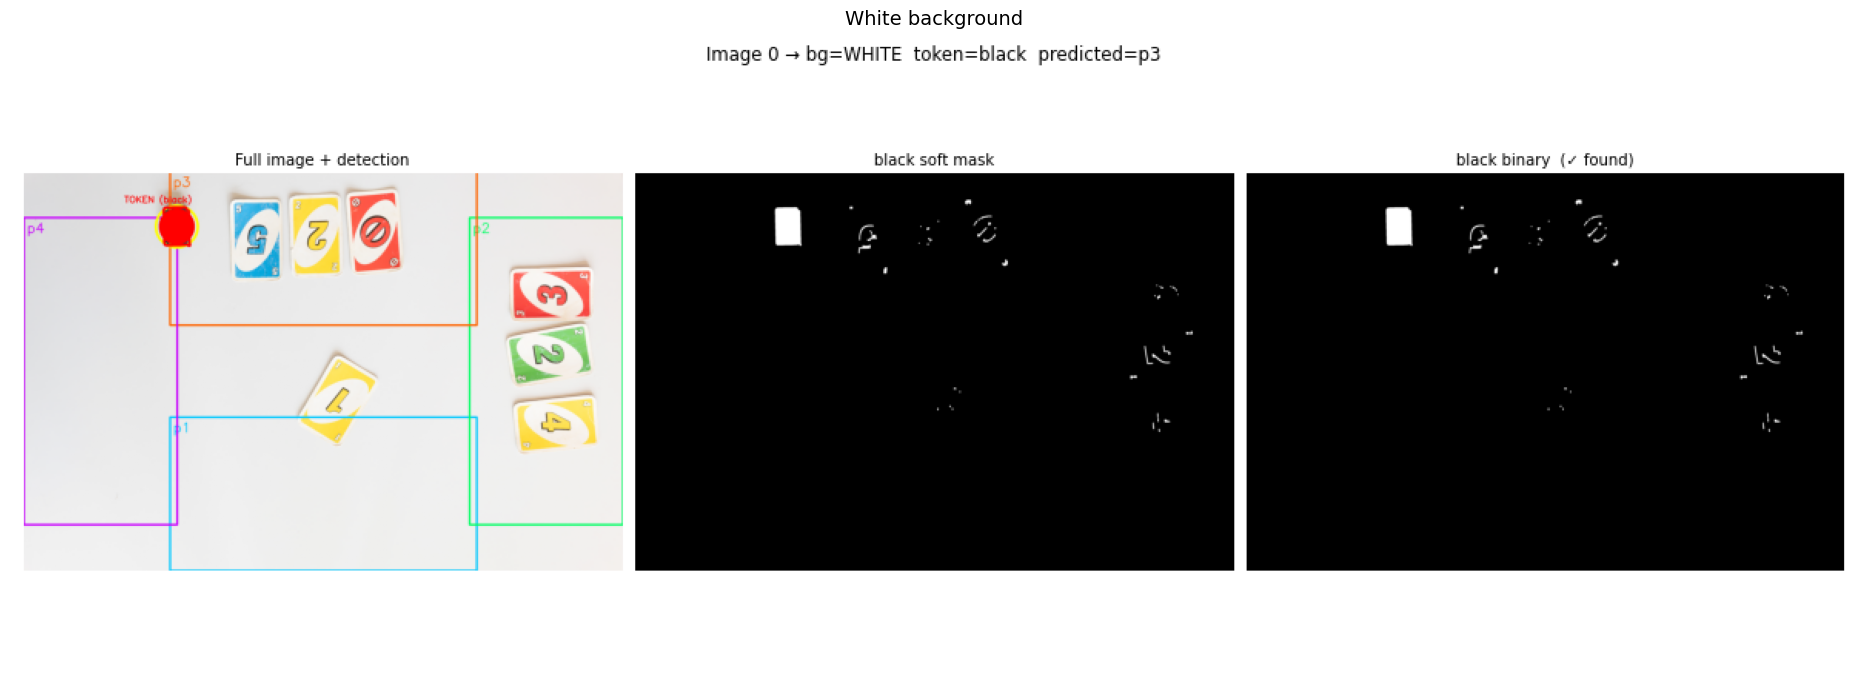

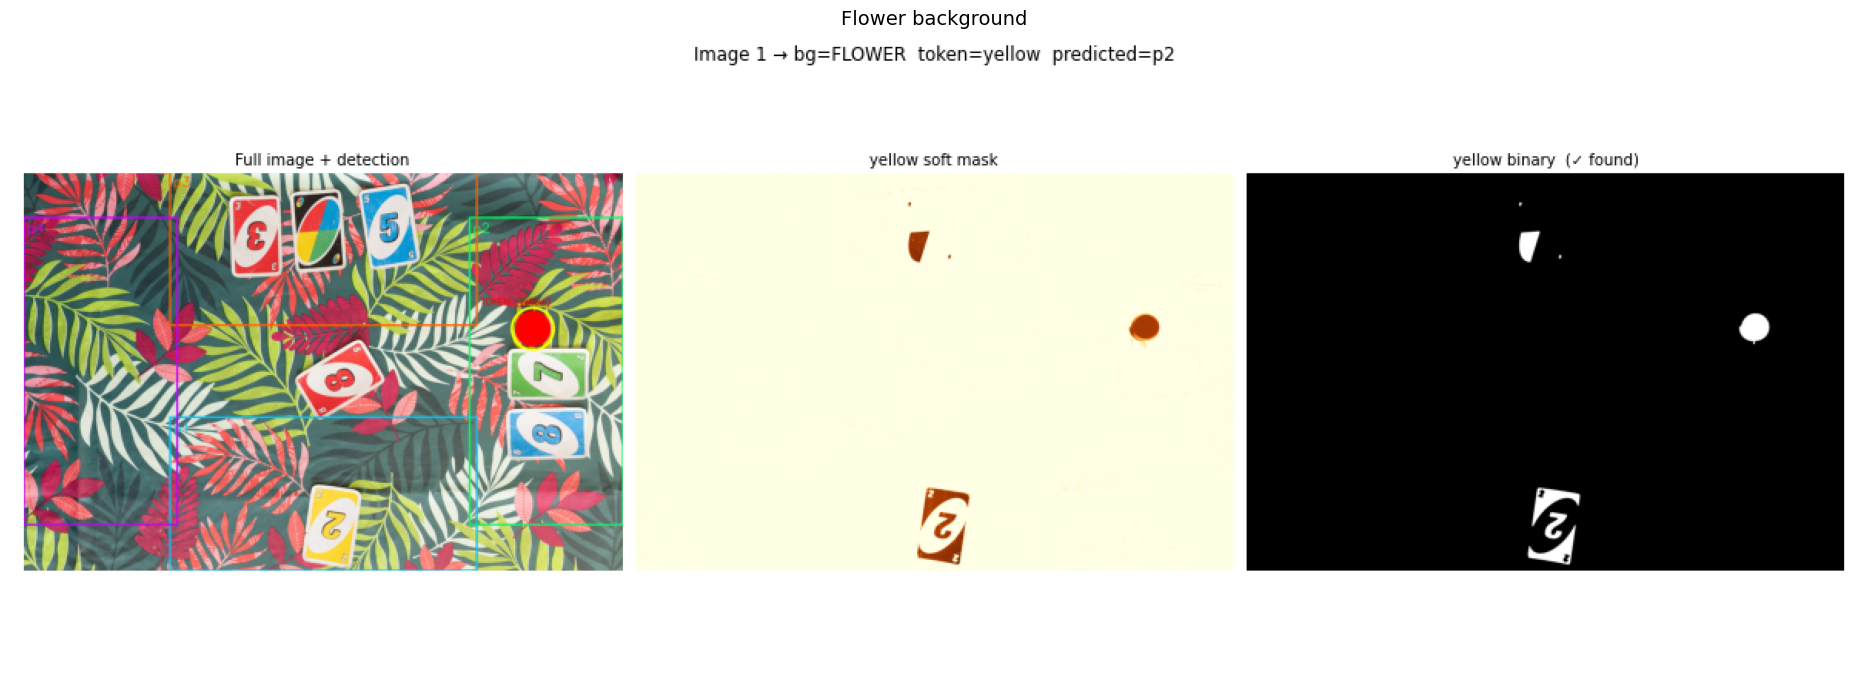

In [2]:
# Load dataset
dataset = load_train_images_paths_and_labels()

# Find one white and one flower background image
white_img, flower_img = None, None
for path, _ in dataset:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    if white_img is None and is_white_background(img):
        white_img = img
    if flower_img is None and not is_white_background(img):
        flower_img = img
    if white_img is not None and flower_img is not None:
        break

# Run detection on both
detect_active_player([white_img, flower_img], debug=True)

# Display both inline
for i, title in enumerate(["White background", "Flower background"]):
    img = mpimg.imread(os.path.join(PARENT_PATH, "tmp", f"debug_image_{i}.png"))
    plt.figure(figsize=(20, 7))
    plt.title(title, fontsize=14)
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

The pipeline achieves 100% accuracy on the full training set of 81 images, correctly detecting and assigning the active player in all cases across both background types.

### 4.2 Preprocessing

##### 4.2.1 Step 1 : Sectors Splitting

First step is splitting the image into 5 equals sectors, making players cards attribution trivial :

Loading train image: c:\Users\killi\Desktop\iapr2026_gr34\project\data\train_images\L1000977.jpg


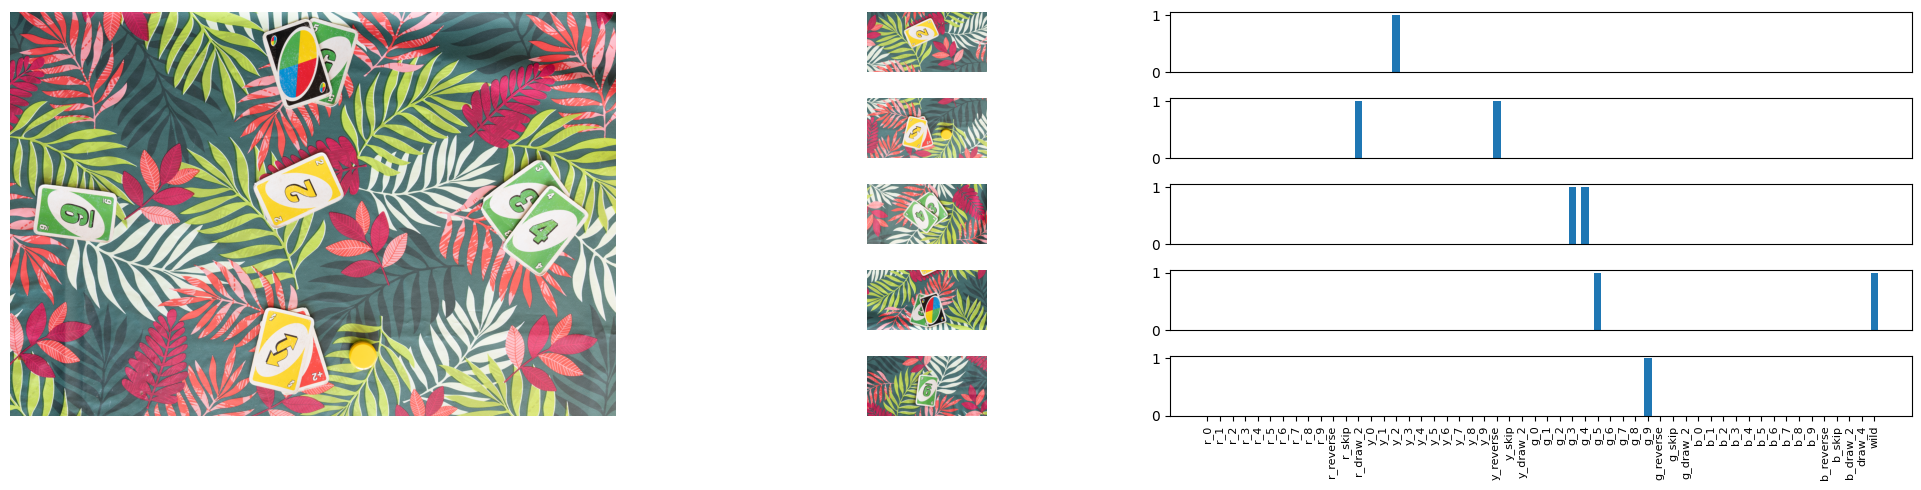

In [3]:
image, label = load_train_image("L1000977")
labels = label.as_binary_vector()
sectors = slice_sectors(image)
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.axis("off")
for i in range(5):
    plt.subplot(5, 3, 2 + 3 * i)
    plt.imshow(sectors[i])
    plt.axis("off")
    plt.subplot(5, 3, 3 + 3 * i)
    plt.bar(np.arange(CARDS_COUNT), labels[i], width=0.6)
    if i < 4:
        plt.xticks([])
    else:
        plt.xticks(np.arange(CARDS_COUNT), [str(c) for c in Card], rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

##### 4.2.2 Step 2 : RYGB Soft Segmentation

Manual segmentation of all cards colors give a visually satisfying result, with distinguishable colors we want to find in our end images :

<p align="center">
    <img src="samples/colors/r.png" width="400"/>
    <img src="samples/colors/y.png" width="400"/>
    <img src="samples/colors/g.png" width="400"/>
    <img src="samples/colors/b.png" width="400"/>
    <img src="samples/colors/k.png" width="400"/>
</p>

Applying a more systematic approach, $\mu$ and $\sigma$ are computed from these images for each color, giving an accurate way of doing **soft segmentation** :

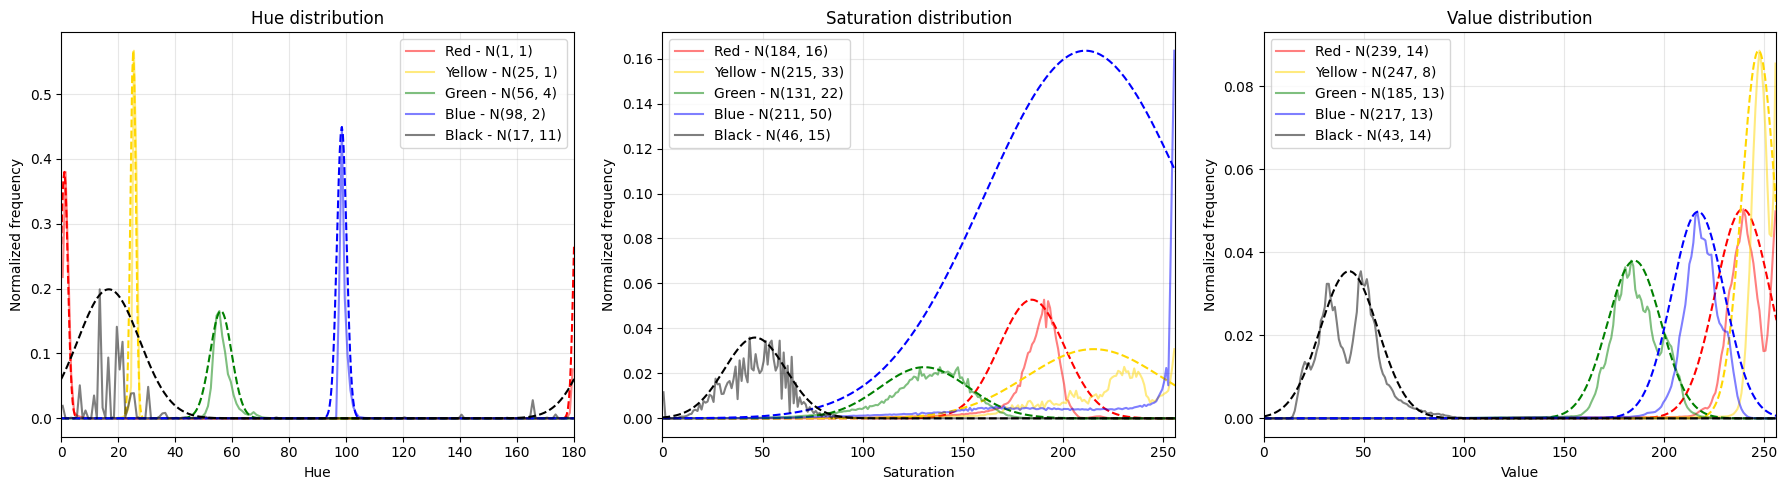

In [4]:
show_ref_cards_color_stats()

The distance heuristic was hardcoded into the `hsv2rygb` function using $\mathcal{N}(\mu, \sigma)$ to soft segment images. A secondary `rygb2rgb` brings the segmentation into a color space we can visualize :

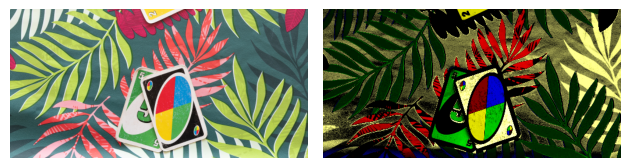

In [5]:
hsv = cv2.cvtColor(sectors[3], cv2.COLOR_RGB2HSV)   # (H, W, 3) Convert to HSV
rygb = hsv2rygb(hsv)                                # (H, W, 4) Soft segment into RYGB
rygb_preview = rygb2rgb(rygb)                       # (H, W, 3) Combine soft segmentation back into an RGB image to be able to show it on screen.
plt.figure()
plt.subplot(121)
plt.imshow(sectors[3])
plt.axis("off")
plt.subplot(122)
plt.imshow(rygb_preview)
plt.axis("off")
plt.tight_layout()
plt.show()

##### 4.2.3 Step 3 : Area Bandpass Filtering

In the code block above, when the random sampler outputs an image with a "flower" backgound, most if it remains. But the gaps left by the white contour of the cards can be used to find regions with the right surface areas :

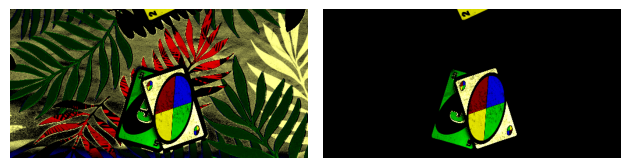

In [6]:
filtered = area_bandpass_filter(rygb)
filtered_preview = rygb2rgb(filtered)
plt.figure()
plt.subplot(121)
plt.imshow(rygb_preview)
plt.axis("off")
plt.subplot(122)
plt.imshow(filtered_preview)
plt.axis("off")
plt.tight_layout()
plt.show()

##### 4.2.4 Putting everything together

The preprocessing pipeline end to end look like follows :

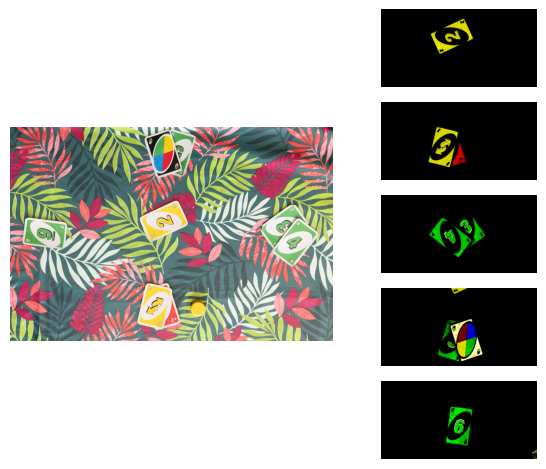

In [7]:
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
for i, sector in enumerate(slice_sectors(image)):
    plt.subplot(5, 2, 2 * (i + 1))
    plt.imshow(rygb2rgb(preprocess(sector)))
    plt.axis("off")
plt.tight_layout()
plt.show()

### 4.3 Classification

#### 4.3.1 Pattern matching

Pattern matching though **normalized cross-correlation** is a reliable way of detecting cards, given distinct enough kernels. However, because it is pretty much a brute-force approach, computing the presence of each card in every orientation with small scalings is very long, taking up to $3$ minutes on each sector.

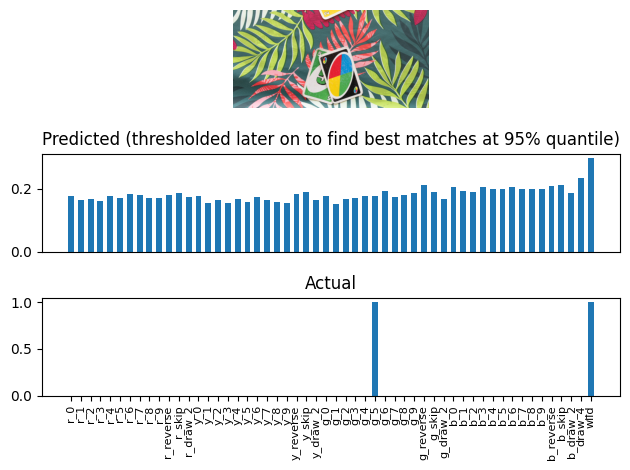

In [8]:
pattern_matcher = PatternMatcher()
predicted = pattern_matcher.match(filtered)
plt.figure()
plt.subplot(311)
plt.imshow(sectors[3])
plt.axis("off")
plt.subplot(312)
plt.title("Predicted (thresholded later on to find best matches at 95% quantile)")
plt.bar(np.arange(CARDS_COUNT), predicted, width=0.6)
plt.xticks([])
plt.subplot(313)
plt.title("Actual")
plt.bar(np.arange(CARDS_COUNT), labels[3], width=0.6)
plt.xticks(np.arange(CARDS_COUNT), [str(c) for c in Card], rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

#### 4.3.2 Machine learning

##### 4.3.2.1 Models

We can compare the different added features :

| Features | F1 Validation |
| :--- | :---: |
| Model Baseline | 0.10 |
| + Synthetic data | 0.20 |
| + Data augmentation | 0.30 |
| + Sobel edge detector | 0.33 |


The final best result we obtained was a score of 0.42 on the Kaggle test with the machine learning approach.

##### 4.3.2.2 Data Sythesizer

While trying to train the model, we realized that with only $81$ images, we would only have $5 \cdot 405$ sectors to train a model on. Any model would quickly overfit and thus never generalize. To address this issue, a data synthesizer was created using the cards reference images, as well as 4 backgrounds and 4 tokens of each color (for each sector).

<p align="center">
    <img src="samples/cards/b_3.png" width="200"/>
    <img src="samples/cards/g_2.png" width="200"/>
    <img src="samples/cards/g_6.png" width="200"/>
    <img src="samples/cards/b_reverse.png" width="200"/>
    <img src="samples/cards/wild.png" width="200"/>
    <img src="samples/cards/y_draw_2.png" width="200"/>
    <img src="samples/tokens/k_4.png" width="50"/>
    <img src="samples/backgrounds/gray_2.png" width="200"/>
    <img src="samples/tokens/y_1.png" width="50"/>
    <img src="samples/backgrounds/flower_4.png" width="200"/>
</p>

After combining all assert with **alpha blending** and random placement, **ambiant**, **diffuse** and **specular** lighting are applied to mimic varying lighting conditions.

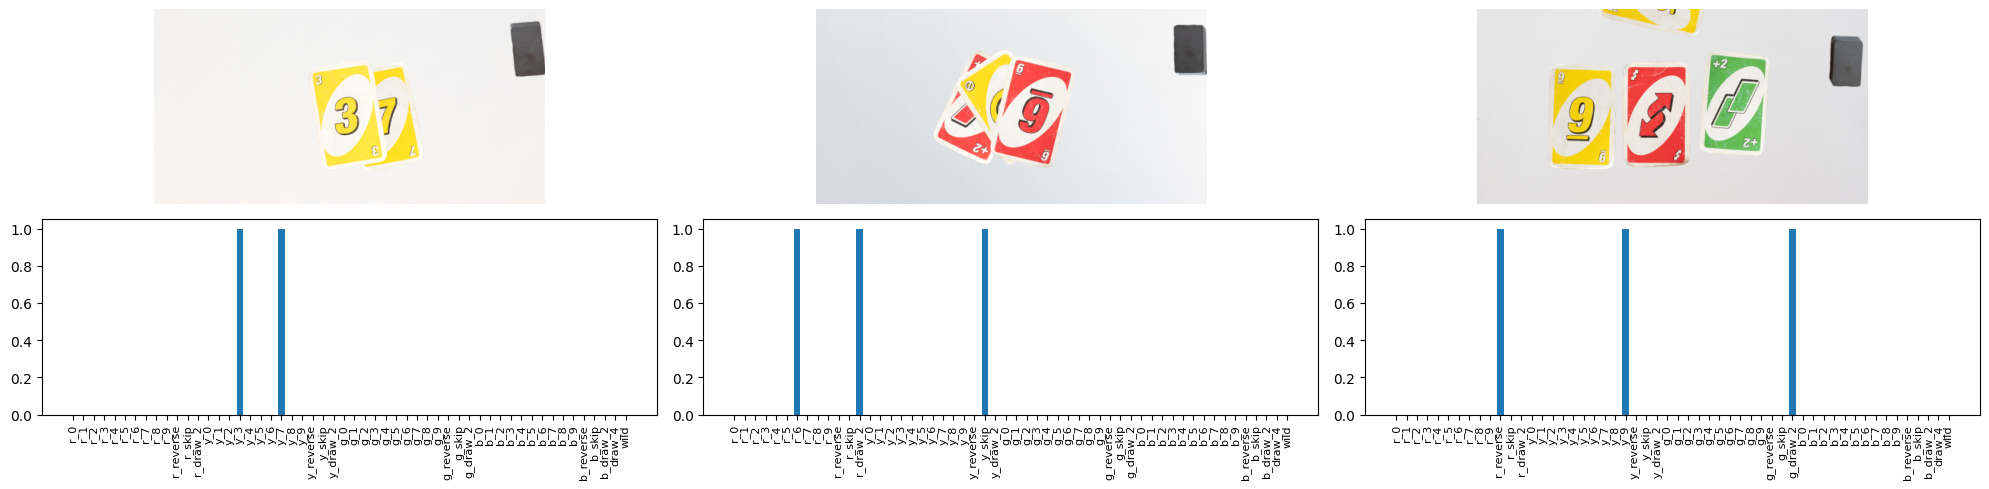

In [9]:
synthesizer = Synthesizer()
plt.figure(figsize=(20, 5))
for i in range(3):
    sector, label = synthesizer.generate()
    plt.subplot(2, 3, i + 1)
    plt.imshow(sector)
    plt.axis("off")
    plt.subplot(2, 3, i + 4)
    plt.bar(np.arange(CARDS_COUNT), label, width=0.6)
    plt.xticks(np.arange(CARDS_COUNT), [str(c) for c in Card], rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

##### 4.3.2.3 Data Cropping

One of the architecture we wanted to try is **JEPA**. For this architecture, the nework requires altered images (often cropped in random places). For this purpose a crop function was prepared, event though it never got to be used.

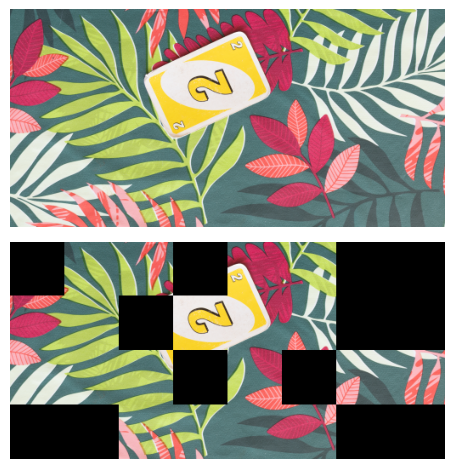

In [10]:
plt.figure()
plt.subplot(211)
plt.imshow(sectors[0])
plt.axis("off")
plt.subplot(212)
plt.imshow(crop(sectors[0]))
plt.axis("off")
plt.tight_layout()
plt.show()

## 5 Discussion

### 5.1 Active Player Detection

The active player detection pipeline behaves differently depending on the background type, and each case comes with its own difficulties.

**Background separation** 

The two background types are treated as completely separate cases since the two token types never co-occur: white backgrounds always use the black token and flower backgrounds always use the yellow token. Separating the two cases keeps each branch simple, interpretable, and independently tunable.

**White background** 

The main difficulty was that the black token is not always perfectly black. Under certain lighting conditions it appears as dark grey, falling outside the HSV threshold and causing the token to be missed. This was mitigated by widening the value threshold to capture dark grey nuances.

**Flower background** 

The yellow segmentation successfully suppresses the leaf pattern. The first challenge was that the token is not always perfectly round, so the circularity threshold was kept loose (circularity > 0.65). This however allowed the UNO yellow Skip card to pass the filter. Since the Skip card symbol is hollow while the token is uniformly filled, a yellow density filter was introduced (yellow_density > 0.55), which reliably rejects hollow card symbols while retaining the solid token.

**Limitation**

The pipeline is entirely rule-based and optimized for this specific configuration, making it highly effective under the conditions specific to the dataset, but potentially vulnerable to novel scenarios, such as new types of tokens, partial occlusions, or significantly different lighting conditions. Since the dataset is fixed and visually consistent, this specialization represents a deliberate and justified trade-off.

### 5.2 Preprocessing

The choice of preprocessing steps was guided by the nature of the objects to classify, which were in this case $54$ cards with $13$ colored cards with $4$ players and a center card.

**Sector splitting**

This is the simplest way to make ownership detection of cards trivial. This steps also embeds downscaling to reduce computational costs in later steps. A nice feature is also that each sector is equally sized, making later steps exactly the same independantly of the processed sector.

**RYGB conversion**

Changing the color space to **RYGB** components is a choice that feels natural for **UNO** cards. This allows easy classification of cards with respect to their colors.

**Background removal**

For background removal, the technique of using **region growing**, then **filtering by surface area** was found to be effective once all color components were merged, thanks to the cards white contours. This technique could probably be refined further to remove the last bits of "flower" background that are left on preprocessed images.

**Object description**

One can notice that we talked about **segmentation** (our preprocessing step) and **classification** but never mentionned the **description** step. There are several reasons for that :
- Our original approach was machine learning for classification, to which giving preprocessed **RYGB** images felt to be a more natural choice.
- When we realized that we wouldn't be able to make **ML** work, we evaluated different ways of describing objects (most notably **Fourier descriptor** for which we had hope), but it turns out that these approaches are much more noisy than plain pattern matching.
- So our conclusion is that we could efficiently describe the colors of our images, but no good way of describing the shapes inside those color channels except keeping all pixels as they were.


### 5.3 Classification

#### 5.3.1 Pattern matching

This approach definetly worked, with an end **F1 score** of $56$%, but it took way too long to run. To generate the submission, the [main](./scripts/__main__.py) file had to be run for approximatley $30$ hours. This is because this was not our original approach, but an emergency solution. Our first approach was to use machine learning to learn patterns with much fewer operations.

We know our naive pattern matching implementation to be heavily optimizable :
- First, convolutions can be computed as multiplications in frequency domain using **FFTs**.
- Second, all cards shouldn't be tested blindly, as we could infer which kernel to test given the color components of the preprocesed image.
- Third, it is probably possible to start convolutions with a coarse stride at the beginning, and then reduce the stride to finer and finer areas.

#### 5.3.2 Machine learning limitations

The performance of the machine learning approach was not very satisfying. We observed that the main struggle of the model was in detecting the correct shape of the 
cards — mainly making mistakes on hard shape classifications that look similar (e.g. 1 and 7).
We can describe the main potential structural limations of our model. 
- Two-stage detection pipeline : We did not have time to implement this approach, but a 
two-stage pipeline could have significantly improved performance: first detecting and cropping 
individual cards within each sector, then classifying each crop independently. In our current 
setup, the model is required to simultaneously localize and classify all cards within a sector, 
which is a considerably harder task. Decoupling detection from classification would allow each 
stage to specialize, likely reducing confusion between visually similar cards.
- Low input resolution : Each sector is downscaled before entering the pipeline. A player 
zone typically contains 3–5 cards spread across the sector, meaning each individual card 
occupies roughly $100 \times 150$ pixels in the network input. At this resolution, fine-grained 
features — card numbers, action symbols — are severely compressed, making it harder for the 
network to distinguish cards that share the same color but differ only in their printed symbol. 
We experimented with a relatively high resolution of $520 \times 520$, but using the full 
original resolution may have further alleviated this bottleneck.
- Synthetic-to-real domain gap : This issue may be minimal in our case, as the synthetic 
data were visually very close to the real training images and thus to the test data. Nevertheless,
a residual domain gap remains: subtle differences in lighting conditions, card surface texture, 
glare, and partial occlusions are difficult to fully replicate procedurally.


## 7. Conclusion

This project tackled the problem of automatically inferring the full state of an 
UNO game from a single top-down photograph, covering active player detection, 
preprocessing, and card classification.

The **active player detection** pipeline proved to be robust component of the system, achieving 100% accuracy on the full training set. By treating white 
and flower backgrounds as completely separate cases, using HSV thresholding for the black rectangular token and a soft yellow segmentation for the circular token, 
the pipeline remained simple, interpretable, and reliable across all configurations present in the dataset.

The **preprocessing** pipeline also performed well. Splitting the image into fixed spatial sectors made card ownership trivially attributable to each player. Converting 
sectors to the custom RYGB color space proved to be a natural fit for UNO cards, cleanly separating the four card colors. The area bandpass filter, exploiting the 
white card contours as natural separators, effectively removed the flower background that survived the color segmentation step.

For **card classification**, the original plan was to train a CNN on synthesized data generated by compositing reference cards onto backgrounds with randomized 
lighting conditions. Despite building a full data synthesizer and exploring several architectures including JEPA-inspired cropping, the model was unable to generalize 
sufficiently to real images, likely due to the domain gap between synthesized and 
real photographs and the limited size of the training set (81 images).

As an alternative, a classical **template matching** approach was adopted, computing normalized cross-correlation between each preprocessed sector and a library of 54 
reference card patterns in the RYGB color space. The matching was made robust to card orientation and scale by sweeping over 32 rotation angles and 8 scale factors. 
This method achieved an F1 score of 56% on the Kaggle challenge, at the cost of a 
very long inference time (~30 hours for the full submission). Known optimizations (FFT-based convolutions, color-guided kernel selection, and coarse-to-fine spatial 
search) were identified but not implemented within the project timeline.